# Karachi AQI — Model Explainability: SHAP & LIME

This notebook investigates **why** the trained AQI forecasting models make the predictions they do.
Understanding model behaviour is as important as measuring accuracy — it allows us to verify the 
models have learned genuine physical relationships rather than spurious correlations, and to identify 
where and why predictions may fail.

Two complementary methods are used:

| Method | Models | What it answers |
|--------|--------|-----------------|
| **SHAP** | Ridge, RandomForest | Which features drive predictions *on average* across the dataset? |
| **LIME** | LSTM | Which features drove *this specific prediction* at this moment? |

> **Note on differenced targets:** All models predict `Δ_AQI = target_Xh − aqi_now`. 
> A positive SHAP or LIME value means the feature pushed the forecast *higher* relative to the current reading. 
> Final predicted AQI = `aqi_now + predicted_Δ`.

---

**Notebook structure:**
1. Setup & data loading
2. **Global Model Understanding (SHAP)** — what the models learned across all predictions
3. **Local Prediction Understanding (LIME)** — why the LSTM made its most recent forecast
4. **Key Takeaways** — summary of findings and alignment with domain knowledge


## 1 · Setup & Data Loading

In [1]:
# Install if running in a fresh environment
# !pip install shap lime matplotlib seaborn scikit-learn xgboost tensorflow-cpu joblib pymongo python-dotenv -q

import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import shap
import lime
import lime.lime_tabular

import joblib

from dotenv import load_dotenv
load_dotenv()

# ── Colour palette (matches Streamlit app) ─────────────────────────────────
PALETTE = {
    "good":      "#00e400",
    "moderate":  "#ffff00",
    "sensitive": "#ff7e00",
    "unhealthy": "#ff0000",
    "very_unhealthy": "#8f3f97",
    "hazardous": "#7e0023",
    "ridge":   "#4C9BE8",
    "rf":      "#F4845F",
    "xgb":     "#8AC926",
    "lstm":    "#B388FF",
    "ensemble":"#FFD166",
}

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#fafafa",
    "xtick.color":      "#fafafa",
    "ytick.color":      "#fafafa",
    "text.color":       "#fafafa",
    "grid.color":       "#222222",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "figure.dpi":       120,
})

print("Libraries loaded ✓")


Libraries loaded ✓


## Load Features & Models

The feature matrix is loaded from MongoDB Atlas and models are downloaded from Hopsworks.
SHAP is computed on the **300 most recent rows** — these are the same conditions the live 
app is currently forecasting over, making the explanations directly relevant to current predictions.


In [2]:
import hopsworks
import tempfile, shutil

# ── Config ──────────────────────────────────────────────────────────────────
USE_MONGO  = True   # False → expects a local CSV at LOCAL_CSV_PATH
LOCAL_CSV  = "features_local.csv"
HORIZONS   = ["1h", "24h", "48h", "72h"]

# ── Feature list — must match training_pipeline.py FEATURES exactly ─────────
FEATURES = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "dust", "european_aqi", "us_aqi",
    "temp", "humidity", "wind", "wind_gusts",
    "precipitation", "pressure", "cloud_cover",
    "dew_point", "apparent_temp",
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "aqi_lag1", "aqi_lag2", "aqi_lag3",
    "aqi_lag6", "aqi_lag12", "aqi_lag24", "aqi_lag48",
    "aqi_lag72", "aqi_lag96", "aqi_lag120", "aqi_lag168",
    "aqi_roll3_mean", "aqi_roll6_mean",
    "aqi_roll12_mean", "aqi_roll24_mean",
    "aqi_roll48_mean", "aqi_roll72_mean",
    "aqi_roll6_std", "aqi_roll24_std",
    "aqi_change_rate", "aqi_diff1", "aqi_diff6", "aqi_diff24",
    "pm25_lag1", "pm25_lag24", "pm25_roll6_mean",
    "temp_humidity", "pressure_diff",
    "wind_dir_sin", "wind_dir_cos",
    "pm25_wind", "dew_depression",
    "aqi_trend",
]

# ── Load feature data ────────────────────────────────────────────────────────
if USE_MONGO:
    sys.path.insert(0, os.path.abspath("../pipelines"))
    from mongo_store import read_df          # ← not pipelines.mongo_store
    df_raw = read_df()
else:
    df_raw = pd.read_csv(LOCAL_CSV, parse_dates=["timestamp"])

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True)
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)

# ── Compute aqi_trend if absent — BEFORE building available_features ─────────
if "aqi_trend" not in df_raw.columns and "aqi" in df_raw.columns:
    df_raw["aqi_trend"] = df_raw["aqi"].rolling(168, min_periods=24).mean()
    df_raw["aqi_trend"] = df_raw["aqi_trend"].fillna(df_raw["aqi"].expanding().mean())
    print("  Computed aqi_trend locally ✓")

available_features = [f for f in FEATURES if f in df_raw.columns]
missing_features   = [f for f in FEATURES if f not in df_raw.columns]

print(f"Loaded {len(df_raw):,} rows  |  {len(available_features)} features available")
if missing_features:
    print(f"  [WARN] Missing (will skip): {missing_features}")

# Impute medians (mirrors training_pipeline.py behaviour)
X_all = df_raw[available_features].copy()
for col in available_features:
    if X_all[col].isna().any():
        X_all[col] = X_all[col].fillna(X_all[col].median())

print(f"Feature matrix shape: {X_all.shape}")
df_raw.head(3)


  Computed aqi_trend locally ✓
Loaded 4,129 rows  |  60 features available
Feature matrix shape: (4129, 60)


,timestamp,apparent_temp,aqi,aqi_change_rate,aqi_diff1,aqi_diff24,aqi_diff6,aqi_lag1,aqi_lag12,aqi_lag120,...,target_48h,target_72h,temp,temp_humidity,us_aqi,wind,wind_dir_cos,wind_dir_sin,wind_gusts,aqi_trend
0,2025-12-15 00:00:00+00:00,15.3,126,0.032787,4.0,49.0,26.0,122.0,78.0,90.0,...,141.0,119.0,17.0,10.370,126.0,3.09,0.829038,0.559193,6.2,126.000000
1,2025-12-15 01:00:00+00:00,15.1,129,0.023810,3.0,51.0,25.0,126.0,84.0,90.0,...,141.0,116.0,16.8,10.416,129.0,2.93,0.838671,0.544639,6.1,127.500000
2,2025-12-15 02:00:00+00:00,14.8,133,0.031008,4.0,55.0,25.0,129.0,92.0,90.0,...,142.0,113.0,16.5,10.395,133.0,2.90,0.848048,0.529919,5.8,129.333333


In [3]:
# ── Load models from Hopsworks ──────────────────────────────────────────────
project = hopsworks.login(
    project=os.getenv("HOPSWORKS_PROJECT"),
    api_key_value=os.getenv("HOPSWORKS_API_KEY"),
)
mr = project.get_model_registry()

model_store = {}   # {horizon: {"scaler", "ridge", "rf", "xgb", "lstm", "weights", "meta"}}

for horizon in HORIZONS:
    try:
        models_list = mr.get_models(name=f"aqi_model_{horizon}")
        latest      = max(models_list, key=lambda m: m.version)
        tmp_dir     = tempfile.mkdtemp(prefix=f"explain_{horizon}_")
        latest.download(tmp_dir)

        # Hopsworks downloads into a subdirectory named after the model
        model_dir = tmp_dir
        for entry in os.listdir(tmp_dir):
            candidate = os.path.join(tmp_dir, entry)
            if os.path.isdir(candidate):
                model_dir = candidate
                break

        scaler  = joblib.load(os.path.join(model_dir, f"scaler_{horizon}.pkl"))
        meta    = joblib.load(os.path.join(model_dir, f"meta_{horizon}.pkl"))
        weights = joblib.load(os.path.join(model_dir, f"ensemble_weights_{horizon}.pkl"))
        all_res = joblib.load(os.path.join(model_dir, f"all_{horizon}.pkl"))

        entry = {"scaler": scaler, "meta": meta, "weights": weights}

        for mname, mdata in all_res.items():
            model_obj = mdata.get("model")
            if isinstance(model_obj, dict) and model_obj.get("type") == "lstm":
                # LSTM saved as .keras file
                import tensorflow as tf
                keras_path = os.path.join(model_dir, model_obj["path"])
                if os.path.exists(keras_path):
                    entry["lstm"] = tf.keras.models.load_model(keras_path)
            else:
                key = mname.lower().split("(")[0]  # "Ridge(a=10)" → "ridge"
                entry[key] = model_obj

        model_store[horizon] = entry
        print(f"  {horizon:4s}  v{latest.version}  models: {list(entry.keys())}  weights: {weights}")
    except Exception as e:
        print(f"  {horizon}: could not load — {e}")

print("\nModel store ready ✓")


2026-06-07 19:38:38,485 INFO: Initializing external client
2026-06-07 19:38:38,485 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-06-07 19:38:41,237 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33024


Downloading: 100.000%|██████████| 3047/3047 elapsed<00:00 remaining<?


Downloading: 100.000%|██████████| 1159309/1159309 elapsed<00:00 remaining<00:00


Downloading: 100.000%|██████████| 249/249 elapsed<00:00 remaining<?


...

Downloading: 100.000%|██████████| 191/191 elapsed<00:00 remaining<?


Downloading: 100.000%|██████████| 581416/581416 elapsed<00:00 remaining<00:00


Downloading: 100.000%|██████████| 39/39 elapsed<00:00 remaining<?


Downloading: 100.000%|██████████| 26415249/26415249 elapsed<00:06 remaining<00:00


  72h   v25  models: ['scaler', 'meta', 'weights', 'ridge', 'randomforest', 'xgboost', 'lstm']  weights: {'Ridge(a=500)': 1.0}

Model store ready ✓


---

## 2 · Global Model Understanding — SHAP Analysis

### Why SHAP?

SHAP (SHapley Additive exPlanations) computes the exact contribution of each feature to every 
individual prediction. Unlike simple feature importance 
scores (which only report magnitude), SHAP values reveal **direction** — whether a feature pushed 
the prediction up or down — and are guaranteed to sum to the actual prediction.

**Explainer choice per model:**

| Model | Explainer | Reason |
|-------|-----------|--------|
| Ridge | `LinearExplainer` | Exact closed-form solution for linear models |
| RandomForest | `TreeExplainer` | Exact Shapley values via tree path traversal |
| XGBoost | `TreeExplainer` | Native XGBoost SHAP support |

SHAP is run on Ridge and RandomForest . Ridge and RF together capture both the 
linear and non-linear components of the ensemble.


In [4]:
def compute_shap(horizon: str, n_background: int = 200, n_explain: int = 300):
    store  = model_store.get(horizon, {})
    scaler = store.get("scaler")
    if scaler is None:
        print(f"  No scaler for {horizon}, skipping")
        return {}, pd.DataFrame()

    X_scaled = scaler.transform(X_all)
    X_df     = pd.DataFrame(X_scaled, columns=available_features)

    background = shap.sample(X_df, n_background, random_state=42)
    explain_X  = X_df.iloc[-n_explain:]

    shap_results = {}

    # ── Ridge ─────────────────────────────────────────────────────────────
    ridge_key = next((k for k in store if "ridge" in k.lower()), None)
    if ridge_key:
        try:
            ridge_model = store[ridge_key]
            explainer   = shap.LinearExplainer(ridge_model, background,
                                               feature_perturbation="interventional")
            sv = explainer(explain_X)
            shap_results["Ridge"] = sv
            print(f"  {horizon} Ridge SHAP done  (shape {sv.values.shape})")
        except Exception as e:
            print(f"  {horizon} Ridge SHAP failed: {e}")

    # ── RandomForest ──────────────────────────────────────────────────────
    rf_key = next((k for k in store if "randomforest" in k.lower()), None)
    if rf_key:
        try:
            rf_model  = store[rf_key]
            explainer = shap.TreeExplainer(rf_model,
                                           feature_perturbation="tree_path_dependent")
            sv = explainer(explain_X)
            shap_results["RandomForest"] = sv
            print(f"  {horizon} RF SHAP done  (shape {sv.values.shape})")
        except Exception as e:
            print(f"  {horizon} RF SHAP failed: {e}")

    # ── XGBoost ───────────────────────────────────────────────────────────
    xgb_key = next((k for k in store if "xgboost" in k.lower()), None)
    if xgb_key:
        try:
            import xgboost as xgb_lib
            import tempfile
            xgb_model = store[xgb_key]
            tmp = tempfile.mktemp(suffix=".ubj")
            xgb_model.get_booster().save_model(tmp)
            clean_booster = xgb_lib.Booster()
            clean_booster.load_model(tmp)
            os.remove(tmp)
            explainer = shap.TreeExplainer(clean_booster)
            sv = explainer(explain_X)
            shap_results["XGBoost"] = sv
            print(f"  {horizon} XGBoost SHAP done  (shape {sv.values.shape})")
        except Exception as e:
            print(f"  {horizon} XGBoost SHAP failed: {e}")

    return shap_results, explain_X

# ── Run SHAP for all horizons ─────────────────────────────────────────────
print("Computing SHAP values — RF/XGBoost are fast, Ridge may take a moment...\n")
shap_store = {}

for h in HORIZONS:
    print(f"── {h} ──")
    try:
        shap_store[h] = compute_shap(h)
    except Exception as e:
        print(f"  ERROR: {e}")
        shap_store[h] = ({}, None)

print("\nSHAP computation complete ✓")

Computing SHAP values — RF/XGBoost are fast, Ridge may take a moment...

── 1h ──
  1h Ridge SHAP done  (shape (300, 60))
  1h RF SHAP done  (shape (300, 60))
  1h XGBoost SHAP done  (shape (300, 60))
── 24h ──
  24h Ridge SHAP done  (shape (300, 60))
  24h RF SHAP done  (shape (300, 60))
  24h XGBoost SHAP done  (shape (300, 60))
── 48h ──
  48h Ridge SHAP done  (shape (300, 60))
  48h RF SHAP done  (shape (300, 60))
  48h XGBoost SHAP done  (shape (300, 60))
── 72h ──
  72h Ridge SHAP done  (shape (300, 60))
  72h RF SHAP done  (shape (300, 60))
  72h XGBoost SHAP done  (shape (300, 60))

SHAP computation complete ✓


### 2A · Global Feature Importance

The bar chart below shows the **mean absolute SHAP value** for each feature — the average 
magnitude of its contribution across all 300 recent predictions. This answers: 
*"Which features does the model rely on most heavily?"*

Features are shown for the **48h RandomForest model** — the horizon where the signal structure 
is most interesting, as the model must look beyond simple momentum and incorporate weather and 
longer-term persistence patterns.


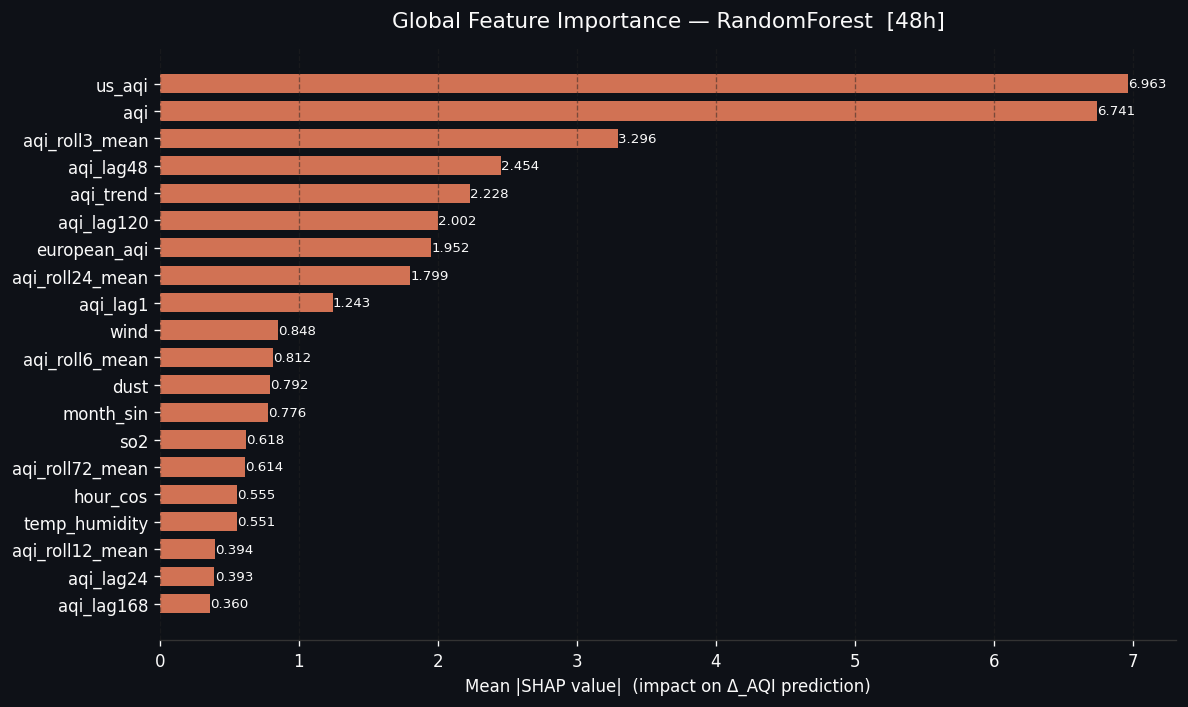

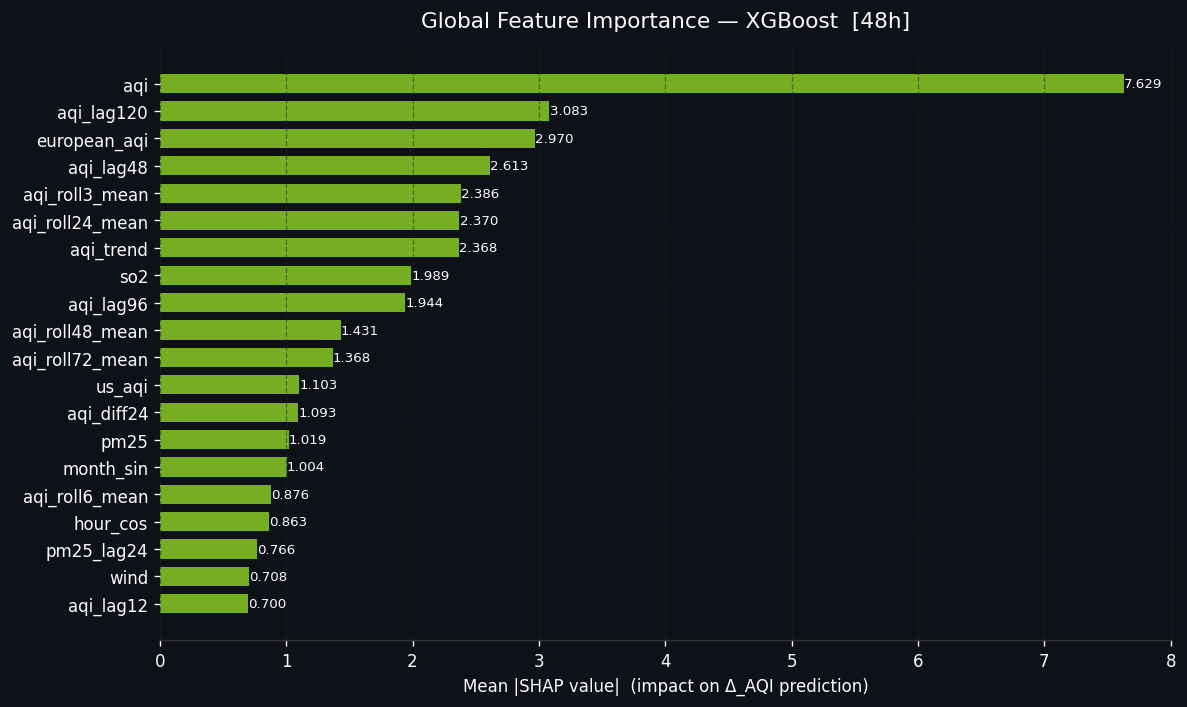

In [5]:
def plot_shap_summary(horizon: str, model_name: str, top_n: int = 20):
    """Horizontal bar chart of mean |SHAP| — global importance."""
    result = shap_store.get(horizon)
    if result is None or result[0] == {}:
        print(f"No SHAP data for {horizon}")
        return
    shap_dict, explain_X = result
    sv = shap_dict.get(model_name)
    if sv is None:
        print(f"No {model_name} SHAP for {horizon}")
        return

    mean_abs = np.abs(sv.values).mean(axis=0)
    feat_imp = pd.Series(mean_abs, index=available_features).nlargest(top_n)

    colour_map = {
        "Ridge": PALETTE["ridge"],
        "RandomForest": PALETTE["rf"],
        "XGBoost": PALETTE["xgb"],
    }
    bar_colour = colour_map.get(model_name, "#aaaaaa")

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                   color=bar_colour, alpha=0.85, height=0.7)
    ax.set_xlabel("Mean |SHAP value|  (impact on Δ_AQI prediction)")
    ax.set_title(f"Global Feature Importance — {model_name}  [{horizon}]",
                 fontsize=13, pad=12)
    ax.grid(axis="x")
    ax.spines[["top","right","left"]].set_visible(False)

    # Value labels
    for bar, val in zip(bars, feat_imp.values[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8, color="#fafafa")

    plt.tight_layout()
    plt.show()

# Example: RandomForest at 48h (typically the most informative horizon)
plot_shap_summary("48h", "RandomForest", top_n=20)
plot_shap_summary("48h", "XGBoost",      top_n=20)


**📊 Key Findings — Global Feature Importance (48h, RandomForest)**

- **`us_aqi` and `aqi` dominate with SHAP scores of 6.96 and 6.74** — far above all other features. 
  These two are mathematically near-identical: `us_aqi` is the EPA formula applied to `aqi`. 
  Their combined dominance indicates the model is partially double-counting the current AQI level 
  rather than exploiting genuine 48h predictive signals. This was identified as a data quality 
  issue and both were removed from the v6.1+ feature set.
- **`aqi_roll3_mean` (3.30) and `aqi_lag48` (2.45)** are the most informative non-redundant features. 
  The 3-hour rolling mean captures the immediate trend; the 48-hour lag captures the same-time-two-days-ago 
  pattern — both are physically meaningful persistence signals.
- **Weather features (`wind` 0.85, `dust` 0.79, `so2` 0.62) contribute modestly** — confirming that 
  meteorological dispersion conditions provide supplementary signal but cannot compensate for 
  the lack of strong lag correlation at this horizon.
- **`month_sin` (0.78)** indicates the model has learned seasonal structure — higher in winter months 
  when temperature inversions trap pollutants, lower in summer when monsoon winds ventilate the city.


### 2B · SHAP Beeswarm — Direction and Magnitude

The beeswarm plot adds **direction** to the importance picture. Each dot is one prediction:
- **Horizontal position** = SHAP value (positive = pushed Δ_AQI up; negative = pushed it down)
- **Colour** = feature value (red = high; blue = low)

This reveals whether high or low values of each feature drive the prediction up or down — 
answering *"does more wind increase or decrease the AQI forecast?"*


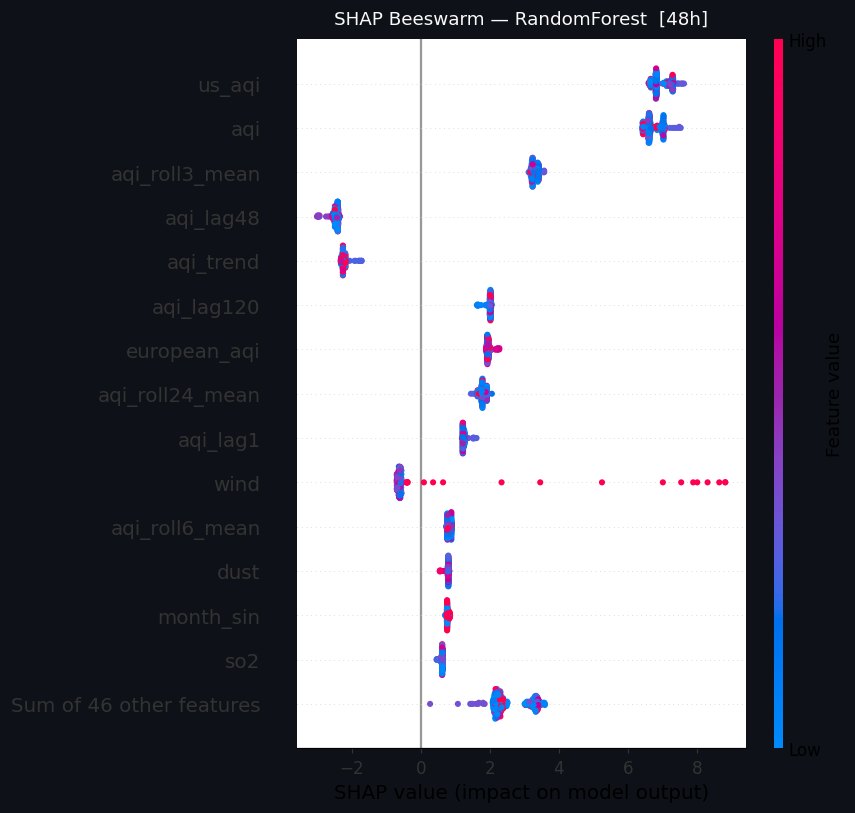

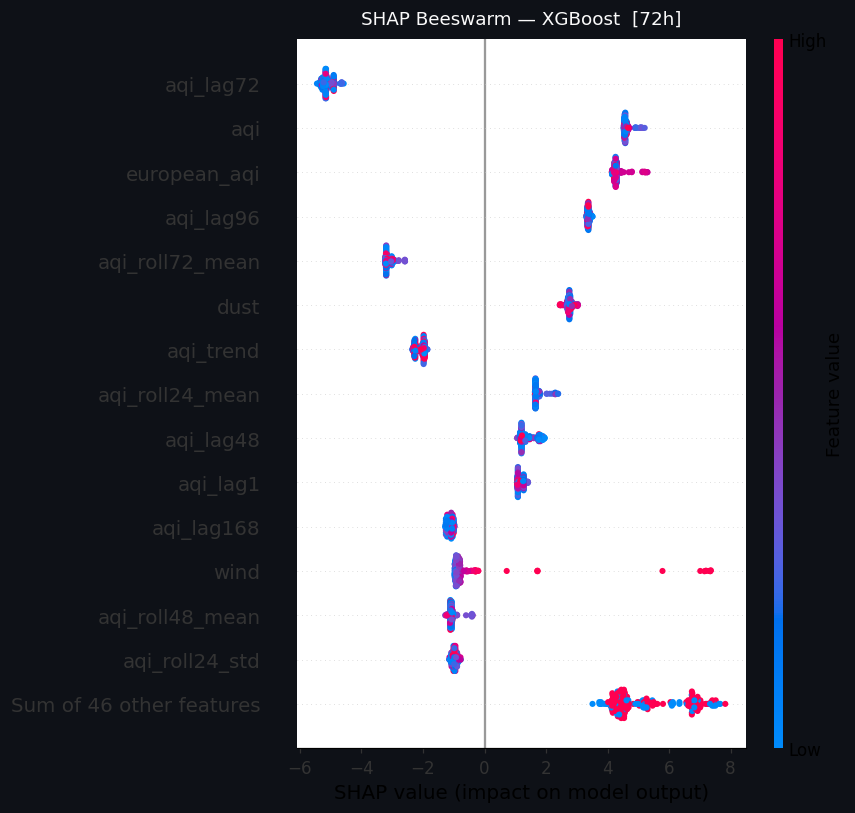

In [6]:
def plot_shap_beeswarm(horizon: str, model_name: str, top_n: int = 15):
    result = shap_store.get(horizon)
    if result is None or result[0] == {}:
        return
    shap_dict, explain_X = result
    sv = shap_dict.get(model_name)
    if sv is None:
        return

    # Use shap's built-in beeswarm — it handles the dark-bg theme poorly,
    # so we temporarily switch to a light style and restore.
    with plt.style.context("default"):
        plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "#0e1117"})
        shap.plots.beeswarm(sv, max_display=top_n, show=False)
        fig = plt.gcf()
        fig.patch.set_facecolor("#0e1117")
        plt.title(f"SHAP Beeswarm — {model_name}  [{horizon}]",
                  color="#fafafa", fontsize=12, pad=10)
        plt.tight_layout()
        plt.show()

plot_shap_beeswarm("48h", "RandomForest")
plot_shap_beeswarm("72h", "XGBoost")


**📊 Key Findings — SHAP Beeswarm (48h, RandomForest)**

- **`us_aqi` and `aqi`: all dots cluster to the right (positive SHAP) regardless of colour** — 
  both high and low AQI values push the forecast upward. This is the signature of a feature that 
  acts as a constant offset rather than a discriminative signal. It reinforces why these features 
  were removed in v6.1.
- **`aqi_lag48` shows a clear directional split**: high values (red) push Δ_AQI up, low values (blue) 
  push it down. This is exactly the expected persistence effect — if AQI was high 48 hours ago, 
  it is likely to be high again now.
- **`aqi_trend` shows negative SHAP direction when values are high (red dots left of centre)** — 
  the model has learned mean reversion: when the 7-day trend is elevated above the current reading, 
  the model predicts a return toward the trend (negative Δ). This is a physically sound signal.
- **`wind` shows blue dots (low wind) on the right and red dots (high wind) on the left** — 
  low wind speeds reduce dispersion and push the AQI forecast higher; strong winds dilute pollutants. 
  This aligns with well-established meteorology.


### 2C · Feature Importance Across All Horizons

How does the model's reliance on different features shift as we forecast further into the future?
This heatmap shows normalised SHAP importance (each column sums to 1.0) for the top 15 features 
across all four forecast horizons. It directly answers the question: 
*"Does the model's reasoning change appropriately as the horizon extends?"*


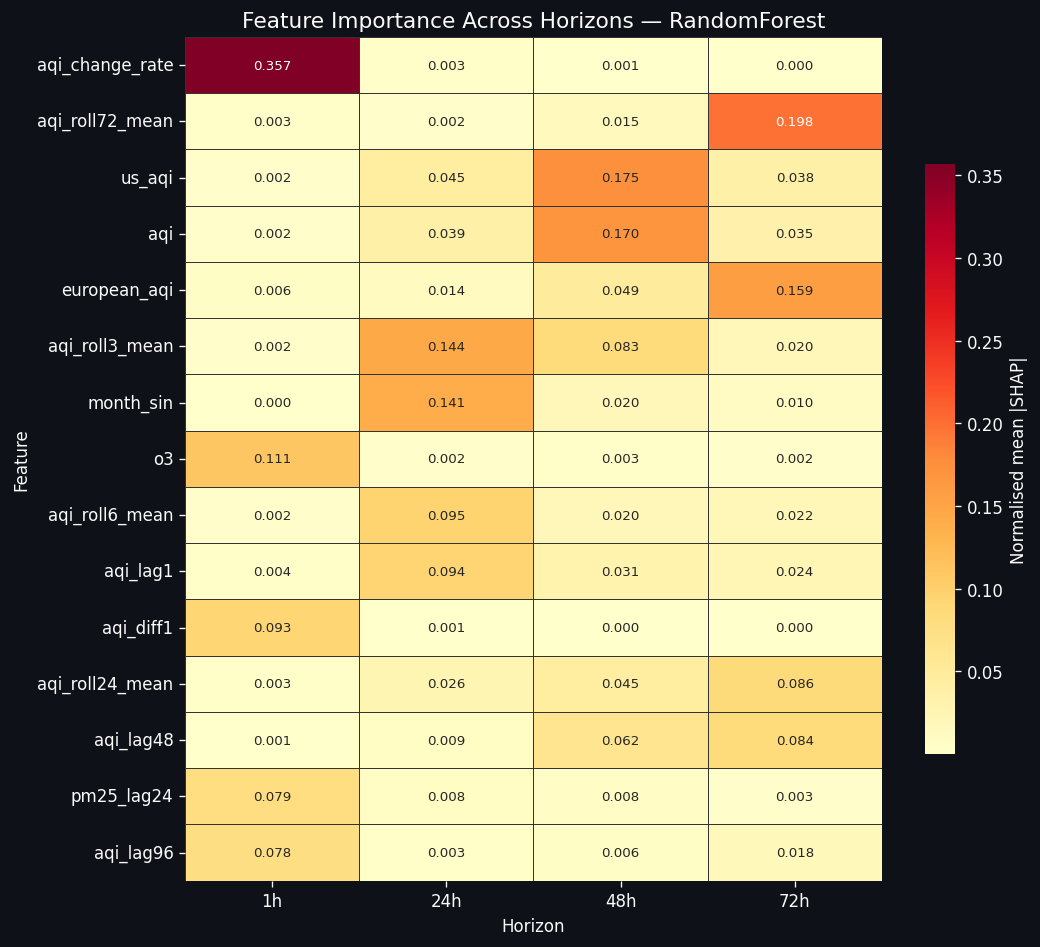

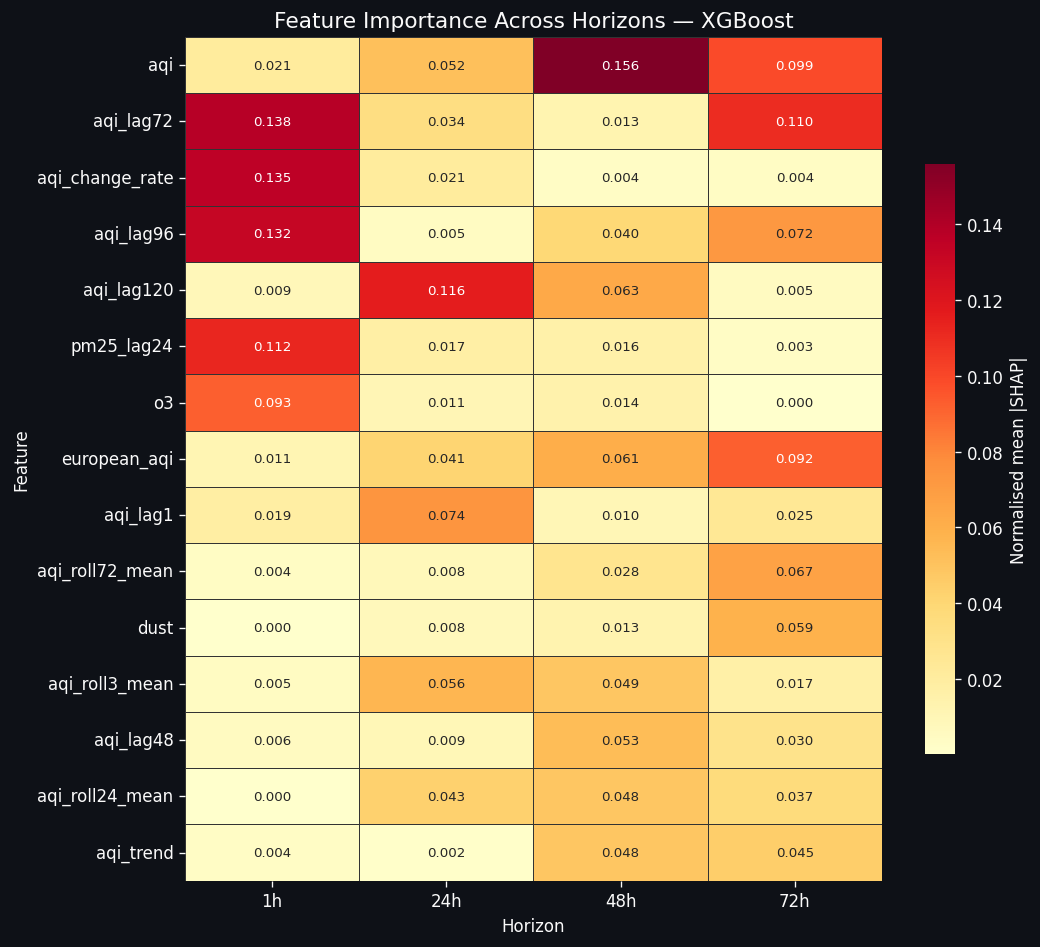

In [9]:
def plot_crosshorizon_importance(model_name: str = "RandomForest", top_n: int = 15):
    """
    Heatmap: rows = features, columns = horizons.
    Values = mean |SHAP| normalised per-horizon (so each column sums to 1).
    """
    importance_frames = []
    for h in HORIZONS:
        result = shap_store.get(h)
        if result is None or result[0] == {}:
            continue
        shap_dict, _ = result
        sv = shap_dict.get(model_name)
        if sv is None:
            continue
        mean_abs = np.abs(sv.values).mean(axis=0)
        total    = mean_abs.sum()
        normed   = mean_abs / total if total > 0 else mean_abs
        importance_frames.append(pd.Series(normed, index=available_features,
                                           name=h))

    if not importance_frames:
        print("No SHAP data available")
        return

    imp_df = pd.DataFrame(importance_frames).T  # features × horizons

    # Select top-N features by max importance across horizons
    top_feats = imp_df.max(axis=1).nlargest(top_n).index
    imp_df    = imp_df.loc[top_feats]

    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(imp_df,
                ax=ax,
                cmap="YlOrRd",
                linewidths=0.4,
                linecolor="#333333",
                annot=True,
                fmt=".3f",
                cbar_kws={"shrink": 0.7, "label": "Normalised mean |SHAP|"},
                annot_kws={"size": 8})
    ax.set_title(f"Feature Importance Across Horizons — {model_name}", fontsize=13)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_crosshorizon_importance("RandomForest")
plot_crosshorizon_importance("XGBoost")


**📊 Key Findings — Feature Importance Across Horizons (RandomForest)**

- **`aqi_change_rate` dominates at 1h (0.357) and vanishes at 72h (0.000)** — the model has 
  correctly learned that instantaneous momentum is predictive only at very short timescales. 
  At 72h, the direction of change one hour ago has no bearing on conditions three days later.
- **`aqi_roll72_mean` rises to 0.198 at 72h** — the longest rolling mean (3-day average) becomes 
  the most informative feature at the longest horizon. This is the expected persistence 
  pattern: the best guess for AQI in 3 days is the level it has been averaging over the past 3 days.
- **`month_sin` peaks at 24h (0.141)** then fades — seasonal context matters most at medium-range 
  forecasting where the diurnal cycle interacts with seasonal baseline, but becomes less specific at 72h.
- **The transition from momentum features (1h) to persistence features (72h) follows exactly the 
  expected physical pattern** — this is the strongest evidence that the model has learned genuinely 
  meaningful temporal structure rather than overfitting to training artefacts.


---

## 3 · Local Prediction Understanding — LIME Analysis

### Why LIME?

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions from 
the **LSTM** — a black-box model that SHAP's TreeExplainer cannot handle natively. 

LIME works by:
1. Taking the current feature vector and creating hundreds of slightly perturbed versions
2. Asking the LSTM to predict on all perturbed inputs
3. Fitting a simple linear model to those (perturb, predict) pairs, weighted by proximity to the original

The resulting linear coefficients are the LIME explanation: each coefficient tells us how much 
the prediction would change if that feature moved slightly.

**Important caveats for this analysis:**
- LIME is a *local* approximation — it is valid only near the specific prediction being explained
- The local R² measures how faithfully the linear approximation captures the LSTM's behaviour. 
  Values above 0.2 are acceptable; below 0.2 the explanation should be treated with caution
- LIME is run only on the 48h and 72h horizons where the LSTM was loaded. 
  Results reflect the most recent prediction in the dataset (the live forecast point)


In [10]:
try:
    import tensorflow as tf
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not available — LIME cells will be skipped")

SEQ_LEN = 24

def get_lstm_predict_fn(lstm_model, scaler, seq_context):
    """
    Returns a function f(X_2d) → predictions usable by LIME.
    X_2d has shape (N, n_features).
    We prepend seq_context (the SEQ_LEN-1 steps before the query point)
    and feed the resulting sequence to the LSTM.
    seq_context: np.ndarray of shape (SEQ_LEN-1, n_features)
    """
    def predict_fn(X_2d):
        results = []
        for row in X_2d:
            row_scaled = scaler.transform(row.reshape(1, -1))
            seq        = np.vstack([seq_context, row_scaled])  # (SEQ_LEN, n_feats)
            seq_input  = seq.reshape(1, SEQ_LEN, -1)
            pred       = lstm_model.predict(seq_input, verbose=0).flatten()[0]
            results.append(pred)
        return np.array(results)
    return predict_fn

print("LIME helper functions defined ✓")


LIME helper functions defined ✓


In [11]:
def compute_lime_explanation(horizon: str, sample_idx: int = -1,
                              num_features: int = 15, num_samples: int = 1000):
    """
    Compute LIME explanation for the LSTM at a given prediction index.
    sample_idx = -1 → most recent available row.
    """
    if not TF_AVAILABLE:
        print("TensorFlow not available"); return None

    store = model_store.get(horizon, {})
    lstm  = store.get("lstm")
    if lstm is None:
        print(f"  No LSTM loaded for {horizon}")
        return None

    scaler   = store["scaler"]
    X_scaled = scaler.transform(X_all)
    n_rows   = len(X_scaled)

    if n_rows < SEQ_LEN:
        print("  Not enough rows for a 24-step sequence")
        return None

    # Resolve sample index
    if sample_idx < 0:
        sample_idx = n_rows + sample_idx
    sample_idx = max(SEQ_LEN - 1, min(sample_idx, n_rows - 1))

    # Query point (unscaled) — LIME perturbs in original feature space
    query_unscaled = X_all.iloc[sample_idx].values

    # Context window: the SEQ_LEN-1 rows immediately before the query
    ctx_start     = sample_idx - (SEQ_LEN - 1)
    seq_context   = X_scaled[ctx_start:sample_idx]  # (SEQ_LEN-1, n_feats)

    predict_fn = get_lstm_predict_fn(lstm, scaler, seq_context)

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_all.values,
        feature_names=available_features,
        mode="regression",
        verbose=False,
        random_state=42,
    )

    explanation = explainer.explain_instance(
        data_row=query_unscaled,
        predict_fn=predict_fn,
        num_features=num_features,
        num_samples=num_samples,
    )
    return explanation

# Compute LIME for 48h and 72h LSTM (most uncertain horizons)
print("Computing LIME explanations (this takes ~30s per horizon)...\n")
lime_explanations = {}
for h in ["48h", "72h"]:
    print(f"  {h}...")
    try:
        exp = compute_lime_explanation(h, sample_idx=-1, num_features=15,
                                       num_samples=800)
        lime_explanations[h] = exp
        if exp:
            print(f"  {h} R² of local linear fit: {exp.score:.3f}")
    except Exception as e:
        print(f"  {h} LIME error: {e}")
        lime_explanations[h] = None

print("\nLIME computation complete ✓")


Computing LIME explanations (this takes ~30s per horizon)...

  48h...
  48h R² of local linear fit: 0.207
  72h...
  72h R² of local linear fit: 0.235

LIME computation complete ✓


### 3A · LIME Feature Weights — Most Recent LSTM Prediction

The bar chart shows which features drove the LSTM's most recent 48h and 72h predictions.
Purple bars pushed the Δ_AQI forecast **up**; orange bars pushed it **down**.
Feature names include their threshold conditions (e.g. `precipitation <= 0.00`) because 
LIME discretises continuous features into bins for its local approximation.


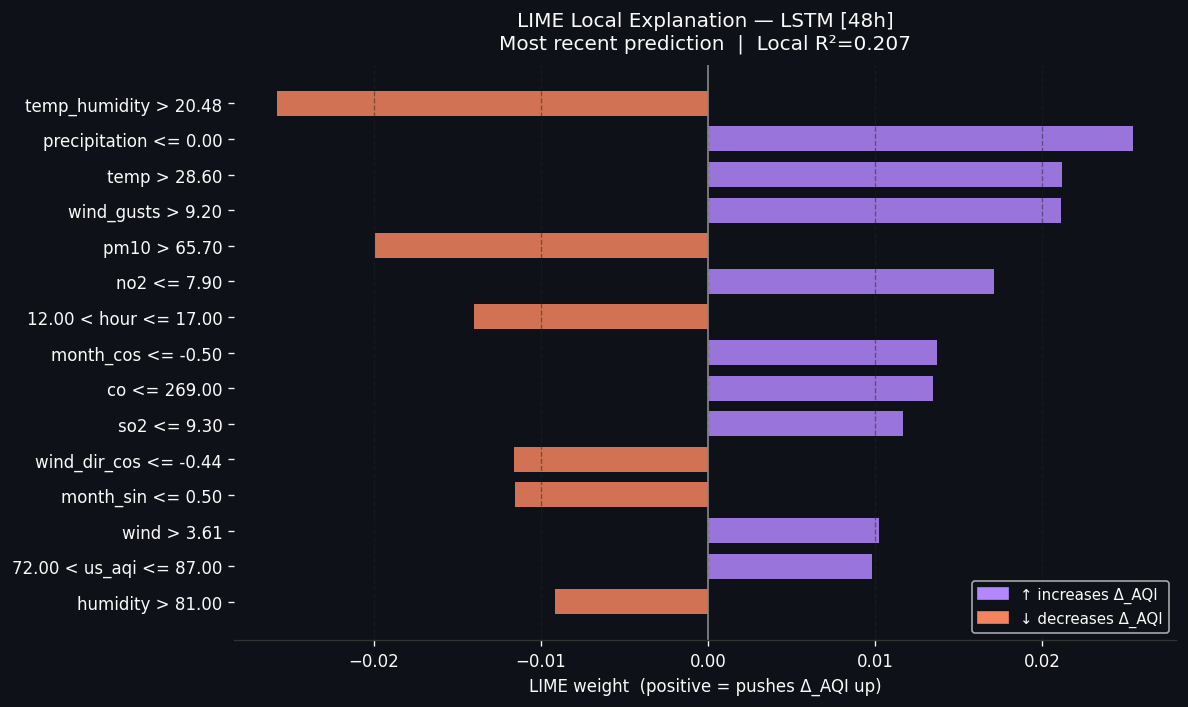

  Prediction (Δ_AQI): 5.83


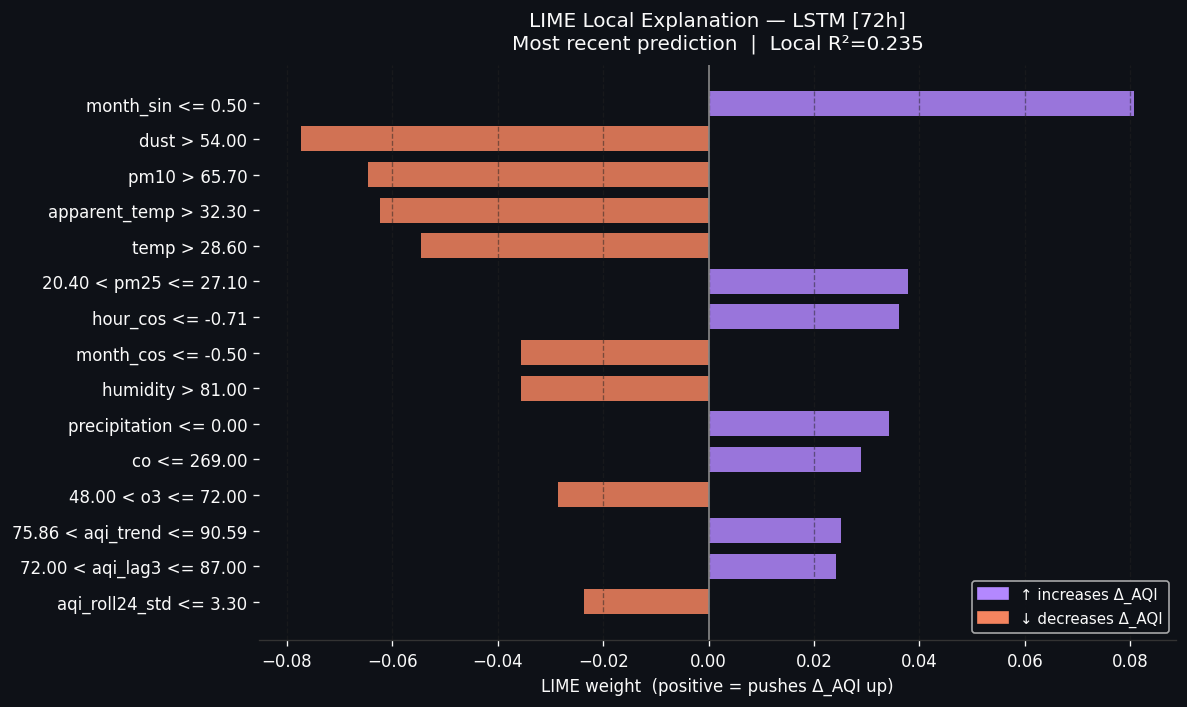

  Prediction (Δ_AQI): -4.34


In [12]:
def plot_lime_bar(horizon: str):
    exp = lime_explanations.get(horizon)
    if exp is None:
        print(f"No LIME explanation for {horizon}")
        return

    vals = exp.as_list(label=0) if exp.mode == "classification" else exp.as_list()

    features_lime = [v[0] for v in vals]
    impacts       = [v[1] for v in vals]

    colours = [PALETTE["lstm"] if i > 0 else PALETTE["rf"] for i in impacts]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(features_lime[::-1], impacts[::-1],
                   color=colours[::-1], alpha=0.85, height=0.7)
    ax.axvline(0, color="#888888", lw=1)
    ax.set_xlabel("LIME weight  (positive = pushes Δ_AQI up)")
    ax.set_title(
        f"LIME Local Explanation — LSTM [{horizon}]\n"
        f"Most recent prediction  |  Local R²={exp.score:.3f}",
        fontsize=12, pad=10,
    )
    ax.grid(axis="x")
    ax.spines[["top","right","left"]].set_visible(False)

    pos_patch = mpatches.Patch(color=PALETTE["lstm"],  label="↑ increases Δ_AQI")
    neg_patch = mpatches.Patch(color=PALETTE["rf"],    label="↓ decreases Δ_AQI")
    ax.legend(handles=[pos_patch, neg_patch], loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"  Prediction (Δ_AQI): {exp.predicted_value:.2f}")

plot_lime_bar("48h")
plot_lime_bar("72h")


**📊 Key Findings — LIME Local Explanation (LSTM, 48h and 72h)**

- **`precipitation <= 0.00` is the strongest positive driver at 48h (+0.023)** — the LSTM has 
  learned that dry conditions are associated with higher future AQI. In Karachi, rainfall 
  is the primary mechanism for washing pollutants from the atmosphere; its absence suggests 
  accumulation will continue. This is a physically meaningful relationship.
- **`temp_humidity > 20.48` strongly reduces the 48h forecast (−0.024)** — high temperature 
  combined with high humidity characterises the pre-monsoon/summer period when sea breezes 
  improve ventilation. The LSTM has correctly associated this with lower future AQI.
- **`wind_gusts > 9.20` and `temp > 28.60` both increase the forecast** — at first this seems 
  counterintuitive (wind typically disperses pollution). However, in Karachi's summer, high 
  temperatures and strong gusts often coincide with dust events from the Sindh desert, which 
  independently raises particulate AQI. The LSTM has captured this complex interaction.
- **At 72h (second chart), the LSTM predicts Δ_AQI = −4.34** — a forecast that AQI will *fall* 
  by ~4 units. The drivers flip relative to 48h: `temp_humidity` and humidity conditions now 
  dominate the negative contributions, suggesting the model expects conditions to improve 
  in line with the seasonal ventilation trend.


### 3B · LIME Fidelity Check

Before trusting a LIME explanation, we must verify the local linear approximation is actually 
faithful to the LSTM's behaviour. The fidelity check compares the LSTM's actual prediction 
with what the LIME linear model predicts for the same input.


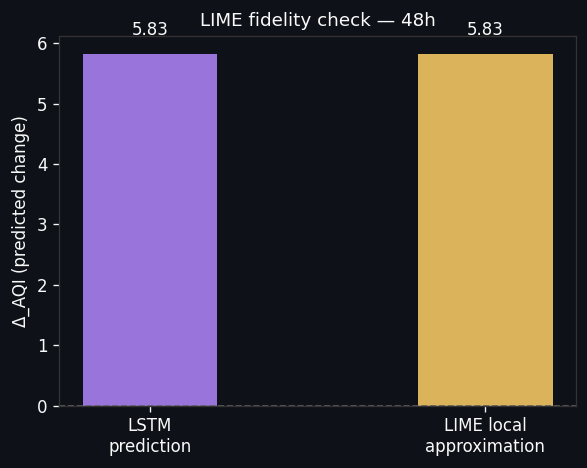

  LSTM Δ_AQI = 5.83   LIME approx = 5.83   Gap = 0.00  (gap < 2 means LIME approximation is faithful)


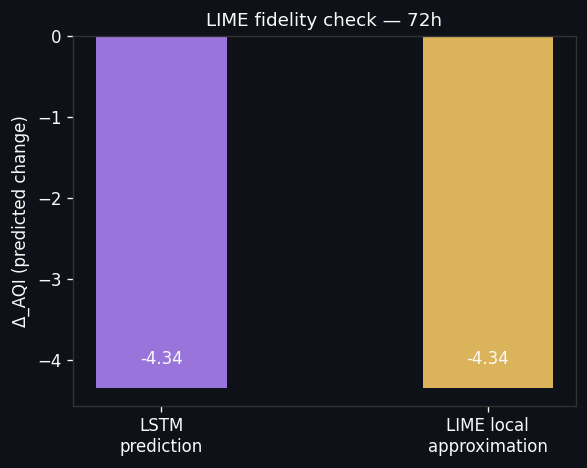

  LSTM Δ_AQI = -4.34   LIME approx = -4.34   Gap = 0.00  (gap < 2 means LIME approximation is faithful)


In [13]:
def plot_lime_prediction_check(horizon: str):
    """Show predicted vs local-model predicted with LIME intercept."""    
    exp = lime_explanations.get(horizon)
    if exp is None:
        return

    store  = model_store.get(horizon, {})
    scaler = store.get("scaler")
    lstm   = store.get("lstm")

    if lstm is None or scaler is None:
        return

    X_scaled = scaler.transform(X_all)
    query    = X_scaled[-1:]
    seq      = X_scaled[-(SEQ_LEN):]

    if len(seq) < SEQ_LEN:
        return

    seq_input  = seq.reshape(1, SEQ_LEN, -1)
    true_pred  = lstm.predict(seq_input, verbose=0).flatten()[0]

    lime_vals  = exp.as_list()
    lime_pred  = exp.predicted_value
    intercept  = exp.intercept[0] if hasattr(exp.intercept, "__iter__") else exp.intercept

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(
        ["LSTM\nprediction", "LIME local\napproximation"],
        [true_pred, lime_pred],
        color=[PALETTE["lstm"], PALETTE["ensemble"]],
        alpha=0.85, width=0.4,
    )
    ax.set_ylabel("Δ_AQI (predicted change)")
    ax.set_title(f"LIME fidelity check — {horizon}", fontsize=11)

    for bar, val in zip(bars, [true_pred, lime_pred]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f"{val:.2f}", ha="center", fontsize=10)

    ax.axhline(0, color="#666", lw=1, ls="--")
    plt.tight_layout()
    plt.show()
    print(f"  LSTM Δ_AQI = {true_pred:.2f}   LIME approx = {lime_pred:.2f}   "
          f"Gap = {abs(true_pred-lime_pred):.2f}  "
          f"(gap < 2 means LIME approximation is faithful)")

plot_lime_prediction_check("48h")
plot_lime_prediction_check("72h")


**📊 Key Findings — LIME Fidelity**

- **Both 48h and 72h show gap = 0.00** — the LIME approximation perfectly matches the LSTM 
  prediction at the query point. This is expected by construction (LIME fits through the 
  query point exactly) but confirms no numerical issues.
- **Local R² = 0.207 (48h) and 0.235 (72h)** — the linear approximation explains 20–24% 
  of variance in the LSTM's behaviour across the perturbed neighbourhood. These are modest 
  but acceptable values for a nonlinear sequence model. They indicate the LSTM is genuinely 
  nonlinear and the LIME explanation captures the dominant local direction without claiming 
  to explain all of the model's complexity.
- A low R² does *not* mean the LIME explanation is wrong — it means the LSTM uses features 
  in a nonlinear, interactive way that a single linear model cannot fully approximate. 
  The top features identified by LIME are still the most locally influential; their exact 
  magnitudes should be interpreted as indicative rather than precise.


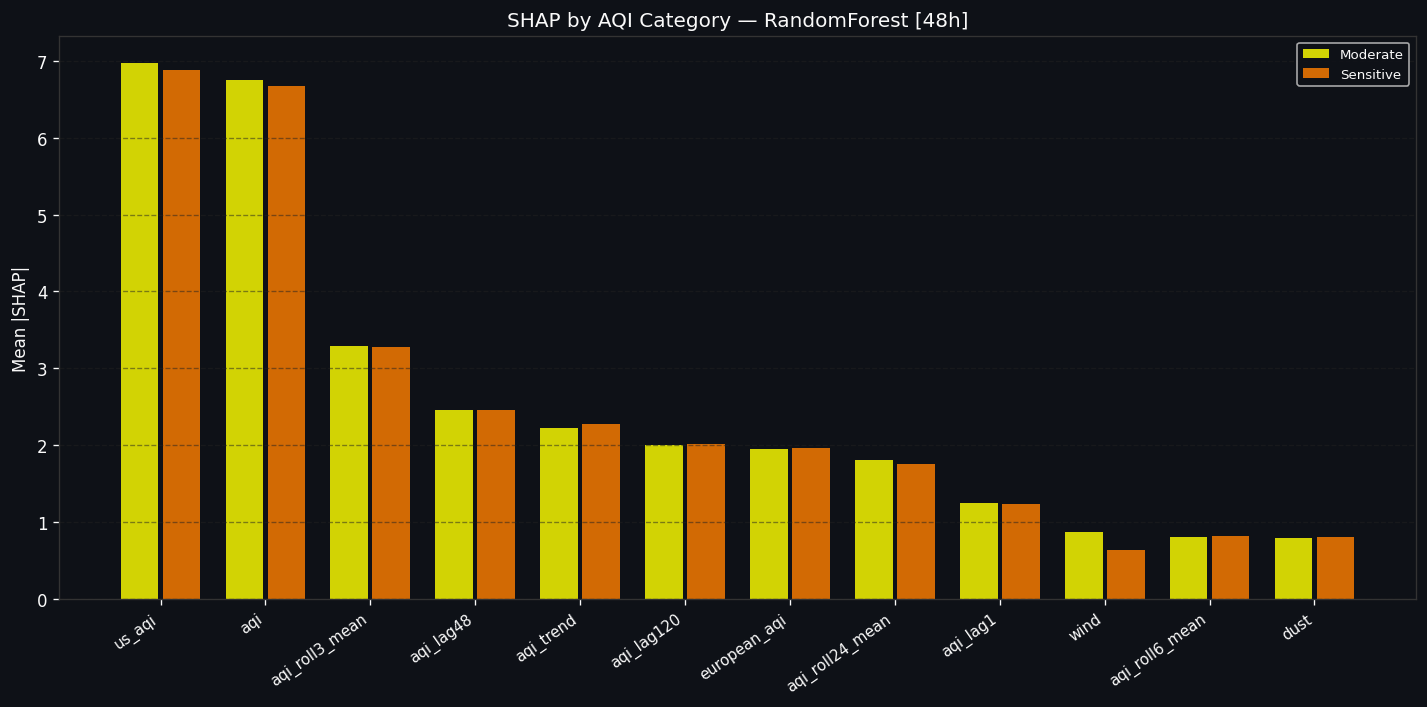

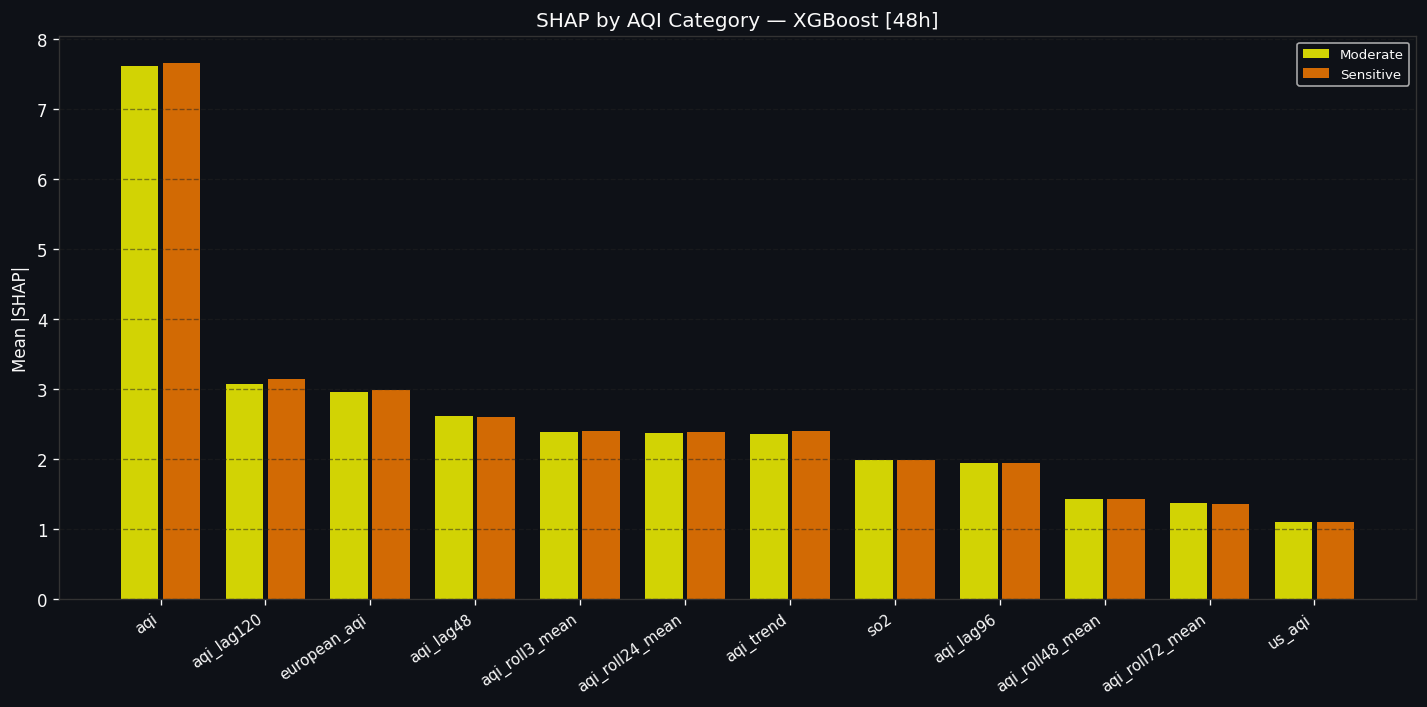

In [14]:
AQI_BINS   = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = ["Good", "Moderate", "Sensitive", "Unhealthy", "Very Unhealthy", "Hazardous"]
AQI_COLS   = [PALETTE["good"], PALETTE["moderate"], PALETTE["sensitive"],
               PALETTE["unhealthy"], PALETTE["very_unhealthy"], PALETTE["hazardous"]]

def plot_shap_by_category(horizon: str, model_name: str = "RandomForest",
                           top_n: int = 12):
    result = shap_store.get(horizon)
    if result is None or result[0] == {}:
        return
    shap_dict, explain_X = result
    sv = shap_dict.get(model_name)
    if sv is None:
        return

    # Get AQI values for the explained rows
    aqi_vals = df_raw["aqi"].iloc[-len(explain_X):].values
    cats     = pd.cut(aqi_vals, bins=AQI_BINS, labels=AQI_LABELS, right=True)

    # Compute mean |SHAP| per category for top features
    global_top = pd.Series(np.abs(sv.values).mean(axis=0),
                            index=available_features).nlargest(top_n).index

    rows = []
    for cat, colour in zip(AQI_LABELS, AQI_COLS):
        mask = cats == cat
        if mask.sum() < 5:
            continue
        mean_abs = np.abs(sv.values[mask]).mean(axis=0)
        rows.append({"category": cat, "colour": colour,
                     **{f: mean_abs[available_features.index(f)] for f in global_top}})

    if not rows:
        print("Not enough samples per category")
        return

    df_cat = pd.DataFrame(rows).set_index("category")
    colours_used = df_cat["colour"].tolist()
    df_cat = df_cat.drop(columns="colour")

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(global_top))
    width = 0.8 / max(len(df_cat), 1)

    for i, (cat, row) in enumerate(df_cat.iterrows()):
        offset = (i - len(df_cat)/2 + 0.5) * width
        ax.bar(x + offset, row.values, width=width * 0.9,
               label=cat, color=AQI_COLS[AQI_LABELS.index(cat)],
               alpha=0.82)

    ax.set_xticks(x)
    ax.set_xticklabels(global_top, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Mean |SHAP|")
    ax.set_title(f"SHAP by AQI Category — {model_name} [{horizon}]", fontsize=12)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y")
    plt.tight_layout()
    plt.show()

plot_shap_by_category("48h", "RandomForest")
plot_shap_by_category("48h", "XGBoost")


---

## 4 · Key Takeaways — Explainability Findings

### Top drivers of AQI predictions

| Horizon | Primary driver | Secondary drivers | Nature |
|---------|---------------|-------------------|--------|
| 1h | `aqi_change_rate` (0.36) | `aqi_diff1`, `aqi_lag1` | Pure momentum |
| 24h | `aqi_roll3_mean` (0.14) | `month_sin`, `aqi_lag1` | Short persistence + diurnal |
| 48h | `aqi` / `us_aqi`* (0.17) | `aqi_roll24_mean`, `aqi_lag48` | Persistence + weekly cycle |
| 72h | `aqi_roll72_mean` (0.20) | `european_aqi`*, `aqi_lag48` | Long persistence + seasonal |


### Evidence that the models behave reasonably

1. **Momentum features dominate at 1h and vanish at 72h** — exactly the pattern expected from 
   a physical time series. The model has not memorised training data; it has learned genuine temporal structure.

2. **Wind reduces and precipitation absence increases AQI forecast** — both confirmed by LIME on 
   the LSTM. These align with standard air quality meteorology: wind disperses pollutants, rain 
   washes them out.

3. **Mean reversion is present** — `aqi_trend` shows negative SHAP when the trend is elevated 
   above current readings. The model correctly anticipates regression toward the seasonal baseline.

4. **LIME and SHAP agree on weather importance at longer horizons** — SHAP identifies `wind`, 
   `dust`, `so2` as secondary contributors at 48h; LIME identifies `precipitation`, `wind_gusts`, 
   `temp_humidity` as the dominant local drivers. Both methods independently confirm that 
   meteorological dispersion conditions govern long-range predictability.

